In [1]:
import os
import numpy as np
import tensorflow as tf

from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential, load_model
from tensorflow.keras.layers import (Dense, Dropout, Activation, Flatten, BatchNormalization, Conv2D, MaxPooling2D)
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping, ReduceLROnPlateau

from sklearn.metrics import (accuracy_score, confusion_matrix, classification_report)

import matplotlib.pyplot as plt

## 1. Основні налаштування

In [2]:
num_classes = 4
img_rows, img_cols = 48, 48
batch_size = 32

train_data_dir = r'train2'
validation_data_dir = r'test2'

epochs = 25

## 2. Генератори даних

In [3]:
# Аугментація для навчання
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    shear_range=0.3,
    zoom_range=0.3,
    width_shift_range=0.4,
    height_shift_range=0.4,
    horizontal_flip=True,
    fill_mode='nearest'
)

# Для валідації / оцінки – тільки нормалізація
val_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_data_dir,
    color_mode='grayscale',
    target_size=(img_rows, img_cols),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

validation_generator = val_datagen.flow_from_directory(
    validation_data_dir,
    color_mode='grayscale',
    target_size=(img_rows, img_cols),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=True
)

# Окремий генератор без перемішування — для метрик
eval_generator = val_datagen.flow_from_directory(
    validation_data_dir,
    color_mode='grayscale',
    target_size=(img_rows, img_cols),
    batch_size=batch_size,
    class_mode='categorical',
    shuffle=False
)

Found 20181 images belonging to 4 classes.
Found 5085 images belonging to 4 classes.
Found 5085 images belonging to 4 classes.


## 3. Модель CNN типу Little VGG

In [4]:
model = Sequential()

# Block-1
model.add(Conv2D(32, (3, 3), padding='same', kernel_initializer='he_normal',
                 input_shape=(img_rows, img_cols, 1)))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(Conv2D(32, (3, 3), padding='same', kernel_initializer='he_normal'))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

# Block-2
model.add(Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal'))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(Conv2D(64, (3, 3), padding='same', kernel_initializer='he_normal'))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

# Block-3
model.add(Conv2D(128, (3, 3), padding='same', kernel_initializer='he_normal'))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(Conv2D(128, (3, 3), padding='same', kernel_initializer='he_normal'))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

# Block-4
model.add(Conv2D(256, (3, 3), padding='same', kernel_initializer='he_normal'))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(Conv2D(256, (3, 3), padding='same', kernel_initializer='he_normal'))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(MaxPooling2D(pool_size=(2, 2)))
model.add(Dropout(0.2))

# Block-5 (Dense)
model.add(Flatten())
model.add(Dense(64, kernel_initializer='he_normal'))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

# Block-6 (Dense)
model.add(Dense(64, kernel_initializer='he_normal'))
model.add(Activation('elu'))
model.add(BatchNormalization())
model.add(Dropout(0.5))

# Block-7 (Output)
model.add(Dense(num_classes, kernel_initializer='he_normal'))
model.add(Activation('softmax'))

print(model.summary())

D:\ProgramFiles\Python3.10\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 48, 48, 32)          │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 48, 48, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 48, 48, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 48, 48, 32)          │           9,248 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 48, 48, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 48, 48, 32)          │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 24, 24, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 24, 24, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 24, 24, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 24, 24, 64)          │          36,928 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_3 (Activation)            │ (None, 24, 24, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 24, 24, 64)          │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 12, 12, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 12, 12, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_4 (Activation)            │ (None, 12, 12, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 12, 12, 128)         │             512 │
│ (BatchNormalization)                 │                             │              

 Total params: 1,327,972 (5.07 MB)

 Trainable params: 1,325,796 (5.06 MB)

 Non-trainable params: 2,176 (8.50 KB)

None


## 4. Callbacks

In [5]:
checkpoint = ModelCheckpoint(
    'Emotion_little_vgg_4cls.h5',
    monitor='val_loss',
    mode='min',
    save_best_only=True,
    verbose=1
)

earlystop = EarlyStopping(
    monitor='val_loss',
    min_delta=0,
    patience=3,
    verbose=1,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.2,
    patience=3,
    verbose=1,
    min_delta=1e-4
)

callbacks = [earlystop, checkpoint, reduce_lr]

## 5. Навчання

In [6]:
model.compile(
    loss='categorical_crossentropy',
    optimizer=Adam(learning_rate=0.001),
    metrics=['accuracy']
)

steps_per_epoch = train_generator.samples // batch_size
validation_steps = validation_generator.samples // batch_size

history = model.fit(
    train_generator,
    steps_per_epoch=steps_per_epoch,
    epochs=epochs,
    callbacks=callbacks,
    validation_data=validation_generator,
    validation_steps=validation_steps
)

Epoch 1/25


D:\ProgramFiles\Python3.10\lib\site-packages\keras\src\trainers\data_adapters\py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


630/630 ━━━━━━━━━━━━━━━━━━━━ 0s 164ms/step - accuracy: 0.2841 - loss: 1.8132
Epoch 1: val_loss improved from inf to 1.31073, saving model to Emotion_little_vgg_4cls.h5


630/630 ━━━━━━━━━━━━━━━━━━━━ 116s 175ms/step - accuracy: 0.2842 - loss: 1.8128 - val_accuracy: 0.3507 - val_loss: 1.3107 - learning_rate: 0.0010
Epoch 2/25
  1/630 ━━━━━━━━━━━━━━━━━━━━ 1:36 154ms/step - accuracy: 0.4062 - loss: 1.3449

D:\ProgramFiles\Python3.10\lib\site-packages\keras\src\trainers\epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


...

630/630 ━━━━━━━━━━━━━━━━━━━━ 108s 171ms/step - accuracy: 0.3345 - loss: 1.3614 - val_accuracy: 0.3655 - val_loss: 1.2918 - learning_rate: 0.0010
Epoch 4/25
  1/630 ━━━━━━━━━━━━━━━━━━━━ 1:56 185ms/step - accuracy: 0.3750 - loss: 1.2904
Epoch 4: val_loss improved from 1.29182 to 1.29134, saving model to Emotion_little_vgg_4cls.h5


630/630 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3750 - loss: 1.2904 - val_accuracy: 0.3689 - val_loss: 1.2913 - learning_rate: 0.0010
Epoch 5/25
630/630 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.3605 - loss: 1.3232
Epoch 5: val_loss improved from 1.29134 to 1.26398, saving model to Emotion_little_vgg_4cls.h5


630/630 ━━━━━━━━━━━━━━━━━━━━ 107s 171ms/step - accuracy: 0.3605 - loss: 1.3232 - val_accuracy: 0.3890 - val_loss: 1.2640 - learning_rate: 0.0010
Epoch 6/25
  1/630 ━━━━━━━━━━━━━━━━━━━━ 1:46 169ms/step - accuracy: 0.3438 - loss: 1.3966
Epoch 6: val_loss improved from 1.26398 to 1.26281, saving model to Emotion_little_vgg_4cls.h5


630/630 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3438 - loss: 1.3966 - val_accuracy: 0.3926 - val_loss: 1.2628 - learning_rate: 0.0010
Epoch 7/25
630/630 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.3793 - loss: 1.3009
Epoch 7: val_loss did not improve from 1.26281
630/630 ━━━━━━━━━━━━━━━━━━━━ 108s 171ms/step - accuracy: 0.3793 - loss: 1.3009 - val_accuracy: 0.3869 - val_loss: 1.3184 - learning_rate: 0.0010
Epoch 8/25
  1/630 ━━━━━━━━━━━━━━━━━━━━ 1:36 154ms/step - accuracy: 0.3125 - loss: 1.2505
Epoch 8: val_loss did not improve from 1.26281
630/630 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.3125 - loss: 1.2505 - val_accuracy: 0.3762 - val_loss: 1.3434 - learning_rate: 0.0010
Epoch 9/25
630/630 ━━━━━━━━━━━━━━━━━━━━ 0s 161ms/step - accuracy: 0.4137 - loss: 1.2528
Epoch 9: val_loss improved from 1.26281 to 1.12036, saving model to Emotion_little_vgg_4cls.h5


630/630 ━━━━━━━━━━━━━━━━━━━━ 108s 171ms/step - accuracy: 0.4138 - loss: 1.2528 - val_accuracy: 0.4966 - val_loss: 1.1204 - learning_rate: 0.0010
Epoch 10/25
  1/630 ━━━━━━━━━━━━━━━━━━━━ 1:46 169ms/step - accuracy: 0.4375 - loss: 1.2985
Epoch 10: val_loss did not improve from 1.12036
630/630 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.4375 - loss: 1.2985 - val_accuracy: 0.4960 - val_loss: 1.1209 - learning_rate: 0.0010
Epoch 11/25
630/630 ━━━━━━━━━━━━━━━━━━━━ 0s 162ms/step - accuracy: 0.4471 - loss: 1.1950
Epoch 11: val_loss did not improve from 1.12036
630/630 ━━━━━━━━━━━━━━━━━━━━ 108s 171ms/step - accuracy: 0.4471 - loss: 1.1949 - val_accuracy: 0.4974 - val_loss: 1.3587 - learning_rate: 0.0010
Epoch 12/25
  1/630 ━━━━━━━━━━━━━━━━━━━━ 1:36 154ms/step - accuracy: 0.5938 - loss: 1.0613
Epoch 12: val_loss did not improve from 1.12036

Epoch 12: ReduceLROnPlateau reducing learning rate to 0.00020000000949949026.
630/630 ━━━━━━━━━━━━━━━━━━━━ 6s 9ms/step - accuracy: 0.5938 - loss: 1.0613 

## 6. Learning loss / accuracy

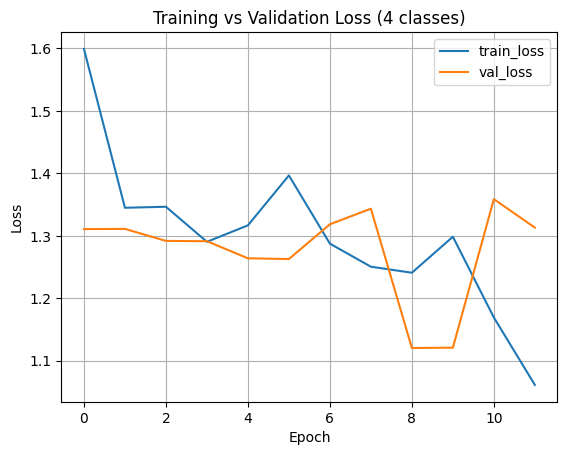

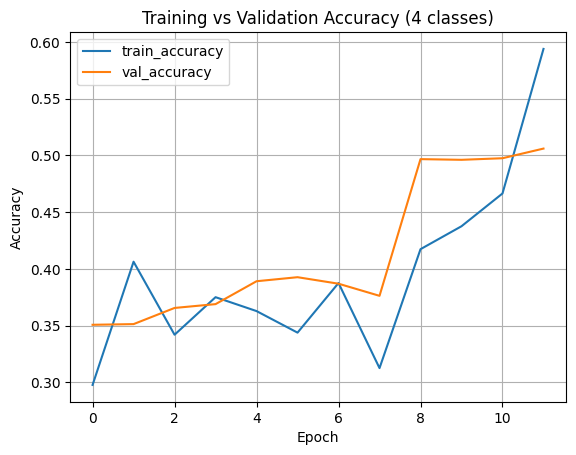

In [7]:
# Loss
plt.figure()
plt.plot(history.history['loss'], label='train_loss')
plt.plot(history.history['val_loss'], label='val_loss')
plt.title('Training vs Validation Loss (4 classes)')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

# Accuracy
plt.figure()
plt.plot(history.history['accuracy'], label='train_accuracy')
plt.plot(history.history['val_accuracy'], label='val_accuracy')
plt.title('Training vs Validation Accuracy (4 classes)')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()


## 7. Оцінка моделі на validation set
###    (accuracy, confusion matrix, precision/recall/F1)

159/159 ━━━━━━━━━━━━━━━━━━━━ 6s 39ms/step
Validation accuracy (4 classes): 0.495968534906588
Classes: ['happy', 'neutral', 'sad', 'surprise']
Confusion matrix:
 [[952 345 234 243]
 [279 451 291 212]
 [394 287 423 143]
 [ 51  51  33 696]]


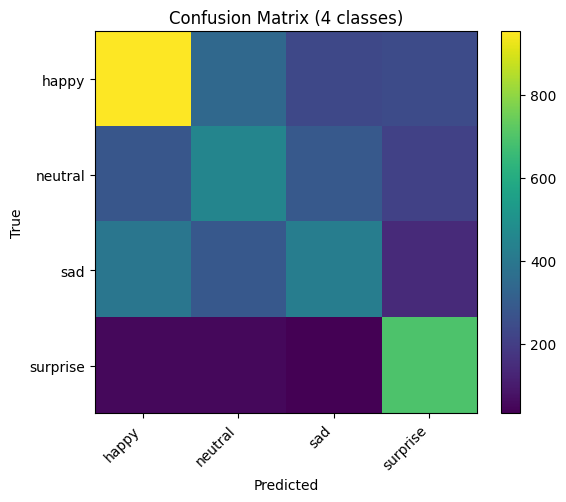

Classification report:
               precision    recall  f1-score   support

       happy     0.5680    0.5366    0.5519      1774
     neutral     0.3977    0.3658    0.3811      1233
         sad     0.4312    0.3392    0.3797      1247
    surprise     0.5379    0.8375    0.6551       831

    accuracy                         0.4960      5085
   macro avg     0.4837    0.5198    0.4919      5085
weighted avg     0.4882    0.4960    0.4851      5085



In [8]:
# Прогнози й істинні мітки
y_prob = model.predict(eval_generator)
y_pred = np.argmax(y_prob, axis=1)
y_true = eval_generator.classes

# Accuracy
val_acc = accuracy_score(y_true, y_pred)
print("Validation accuracy (4 classes):", val_acc)

# Імена класів у правильному порядку
class_indices = eval_generator.class_indices
idx_to_class = {v: k for k, v in class_indices.items()}
class_names = [idx_to_class[i] for i in range(len(idx_to_class))]
print("Classes:", class_names)

# Confusion matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion matrix:\n", cm)

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(cm, interpolation='nearest')
plt.colorbar(im)
ax.set_xticks(np.arange(len(class_names)))
ax.set_yticks(np.arange(len(class_names)))
ax.set_xticklabels(class_names, rotation=45, ha="right")
ax.set_yticklabels(class_names)
ax.set_xlabel("Predicted")
ax.set_ylabel("True")
plt.title("Confusion Matrix (4 classes)")
plt.tight_layout()
plt.show()

# Classification report
report = classification_report(y_true, y_pred, target_names=class_names, digits=4)
print("Classification report:\n", report)